In [1]:
# Last mod: AC Nov 7 - adapted notebook from Jaume's TFG

# Analysing chemistry space of the GALAH DR3 RC catalogue 
### with t-SNE & UMAP,....

In [2]:
import numpy as np
#import matplotlib.pylab as plt
import matplotlib.pyplot as plt    #eina per fer plots  (p.ex: plt.plot(x,y))
import matplotlib.gridspec as gridspec  #grid pels subplots
from matplotlib import colors         #colors
from matplotlib.colors import LogNorm   #normalitza a 0-1 en escala logarítmica 
from matplotlib import patches     #figures
from mpl_toolkits.mplot3d import Axes3D   #eixos en 3D
from mpl_toolkits.axes_grid1 import make_axes_locatable  #per canviar la posició dels eixos
from matplotlib.ticker import NullFormatter   #marques(tics) sense etiquetes en els eixos

import astropy.table     #paquet per manejar taules de dades
from astropy.table import Table, Column, MaskedColumn   #importa taules, columnes i columnes que emmascaren dades invàlides
from astropy.visualization import astropy_mpl_style  #visualització 
from scipy.stats import gaussian_kde  #representation of a kernel-density estimate using Gaussian kernels.
import seaborn as sns  #llibreria per fer gràfics estadístics
import os.path   #per implementar diferents funcions amb pathnames ("dreceres")

from time import time   #mòdul de funcions de time access 
from sklearn import manifold, datasets #manifold: algoritme de dimensionality reduction 
                                       #sklearn (sci-kit learn): llibreria de Python per machine learning

import umap                #Uniform Manifold Approximation and Projection (UMAP) is a dimensionality reduction technique
from sklearn.decomposition import PCA  #Principal component analysis (PCA). Linear dimensionality reduction using Singular Value    
from sklearn.manifold import TSNE #t-SNE [1] is a tool to visualize high-dimensional data
from itertools import product   #producte cartesià

import obtain_data   #per importar dades d'altres fitxers

#from astroML.plotting import setup_text_plots
#setup_text_plots(fontsize=16, usetex=True)

## Preparing the sample (mostra de RedClumps)

### The GALAH DR3 RC sample
The GALAH DR3 red-clump sample is a selection of RC stars from the GALAH DR3 catalogue. I have put together the possibly interesting portions of the catalogs and cut a sample of red clump (RC) stars using topcat: (teff > 4500 && teff < 5100 && logg > 2.3 && logg < 2.55 && is_redclump_bstep > 0.5).
This sample contains 37,417 stars.


In [3]:
import importlib   #package per importar coses a python
importlib.reload(obtain_data)

galah_rc = obtain_data.galah_dr3_rc()   

### Prepare the input arrays for PCA, t-SNE, and umap...

... for all the samples used here. We use the functions built into `open_data.py`. 

In [4]:
galah_rc.get_ndimspace()

### Run umap, tsne and PCA in several possibly interesting configurations

The cell below runs the three algorithms for all the samples and saves the results as fits files: **IF YOU DON'T WANT TO RECOMPUTE EVERYTHING, JUST READ THOSE FILES!**

We explore the hyperparameter configurations suggested by these docs:
* https://opentsne.readthedocs.io/en/latest/parameters.html
* https://distill.pub/2016/misread-tsne/
* https://opentsne.readthedocs.io/en/latest/examples/03_preserving_global_structure/03_preserving_global_structure.html
* https://umap-learn.readthedocs.io/en/latest/parameters.html

In [5]:
# Set hyperparameters for all dimred methods:
components=2

# For tsne & umap:
metrics      = ["euclidean" ]#"cosine", "mahalanobis""mahalanobis" not working by default for sklearn.manifold.TSNE



## in particular for tsne (t-Distributed Stochastic Neighbor Embedding):
perplexities   = [30, 40, 50, 60, 80, 100] #[5, 10, 20, 30, 40, 50, 60, 80, 100, 150, 200]
"""perplejidad: Una perplejidad es más o menos un número objetivo de vecinos para nuestro punto central.
Básicamente, cuanto mayor es la perplejidad, mayor valor tiene la varianza. Mesura de la informació
proporcional a la densitat de dades."""

learning_rates = [10, 100] #[1, 10, 100, 500]
"""learning_rate: si és massa alta les dades poden semblar una pilota (amb qualsevol punt equidistant dels seus veïns).
               #si és baixa les dades es poden veure comprimides en un núvol de punts amb pocs valors atípics"""



## in particular for umap (Uniform Manifold Approximation and Projection):
n_neighbors  = [30, 40, 50, 60, 80, 100] # [5, 10, 20, 30, 40, 50, 60, 80, 100, 150, 200]
"""#n_neighbors: estructura local vs global"""

min_dists    = [0.1, 0.25, 0.5]# [0.0, 0.1, 0.25, 0.5, 0.8, 0.99]
"""#min_dist: distància mínima entre punts. Valors baixos per agrupació de clústers"""

#Info: https://umap-learn.readthedocs.io/en/latest/parameters.html

'#min_dist: distància mínima entre punts. Valors baixos per agrupació de clústers'

DON'T RUN THE CELL BELOW IF YOU DON'T NEED TO:) 
IT TAKES A WHILE TO RECOMPUTE ALL THE umap AND t-SNE MAPS

In [ ]:
pca  = PCA(n_components=components)

metrics=["euclidean"]

# Create empty table
b = Table()
b["ID"] = galah_rc.data["sobject_id"]
print("Running PCA:")
# Fill it with the computed results
pca_result = pca.fit_transform(galah_rc.Xnorm)
b["X_PCA"],  b["Y_PCA"]  = pca_result[:, 0], pca_result[:, 1]
print("...done")
##################
for metric in metrics:
    # Loop over different metrics
    print("Metric ", metric)
    print("Running t-SNE:")
    if metric == "mahalanobis":
        # This is not working for t-SNE yet, so:
        pass
    else:
        for p, lr in product(perplexities, learning_rates):
            print("perplexity=", p, "; learning_rate=", lr)
            tsne = TSNE(random_state=42,n_components=components, verbose=0, perplexity=p, metric=metric,
                        init='pca', learning_rate=lr, early_exaggeration=len(galah_rc.data)/10, n_iter=1000)
            tsne_result = tsne.fit_transform(galah_rc.Xnorm)
            # Save results:
            savestring = metric+"_p"+str(p) + "_lr"+str(lr)
            b["X_tSNE_"+savestring], b["Y_tSNE_"+savestring] = tsne_result[:, 0], tsne_result[:, 1]
    print("Running umap:")
    for nn, md in product(n_neighbors, min_dists):
        print("n_neighbors=", nn, "; min_dist=", md)
        umapp= umap.UMAP(random_state=42,n_components=components, n_neighbors=nn, min_dist=md)
        umap_result = umapp.fit_transform(galah_rc.Xnorm)
        # Save results:
        savestring = metric+"_nn"+str(nn) + "_md"+str(md)
        b["X_umap_"+savestring], b["Y_umap_"+savestring] = umap_result[:, 0], umap_result[:, 1]
# Save it in the dimred_results subfolder
print("Saving results.")
b.write("../data/galah_rc_dimred_hyperparametertest.fits", overwrite=True)

### For each sample, produce a set of plots showing the influence of the hyperparameters:

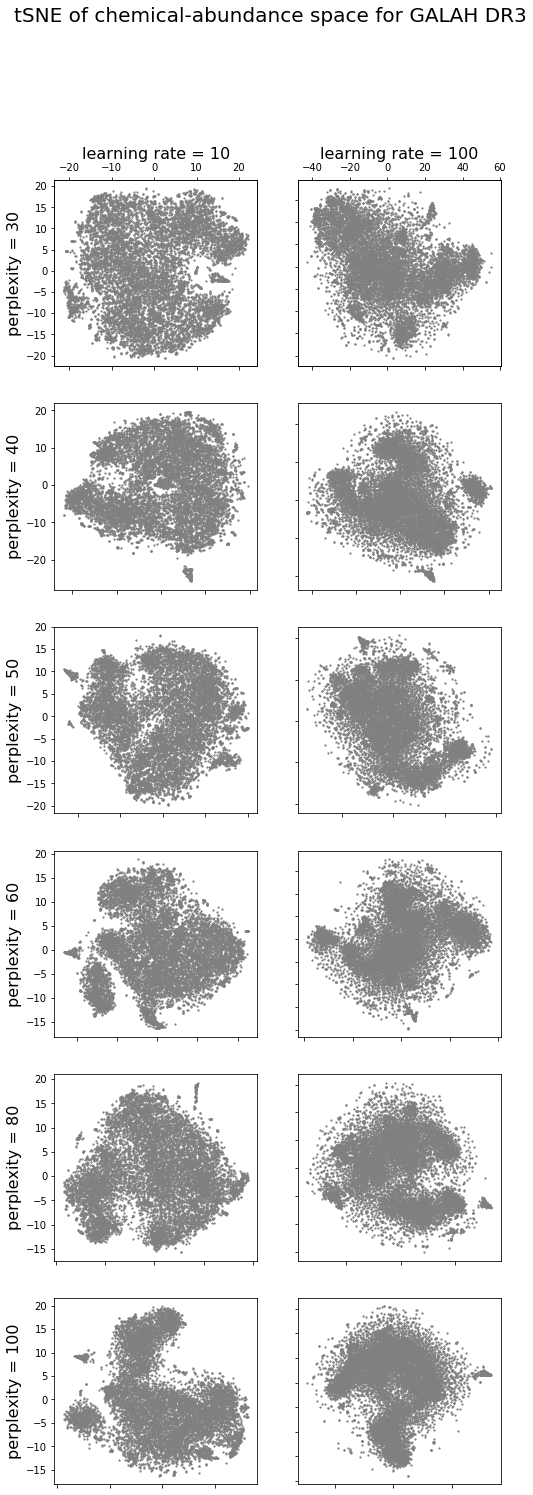

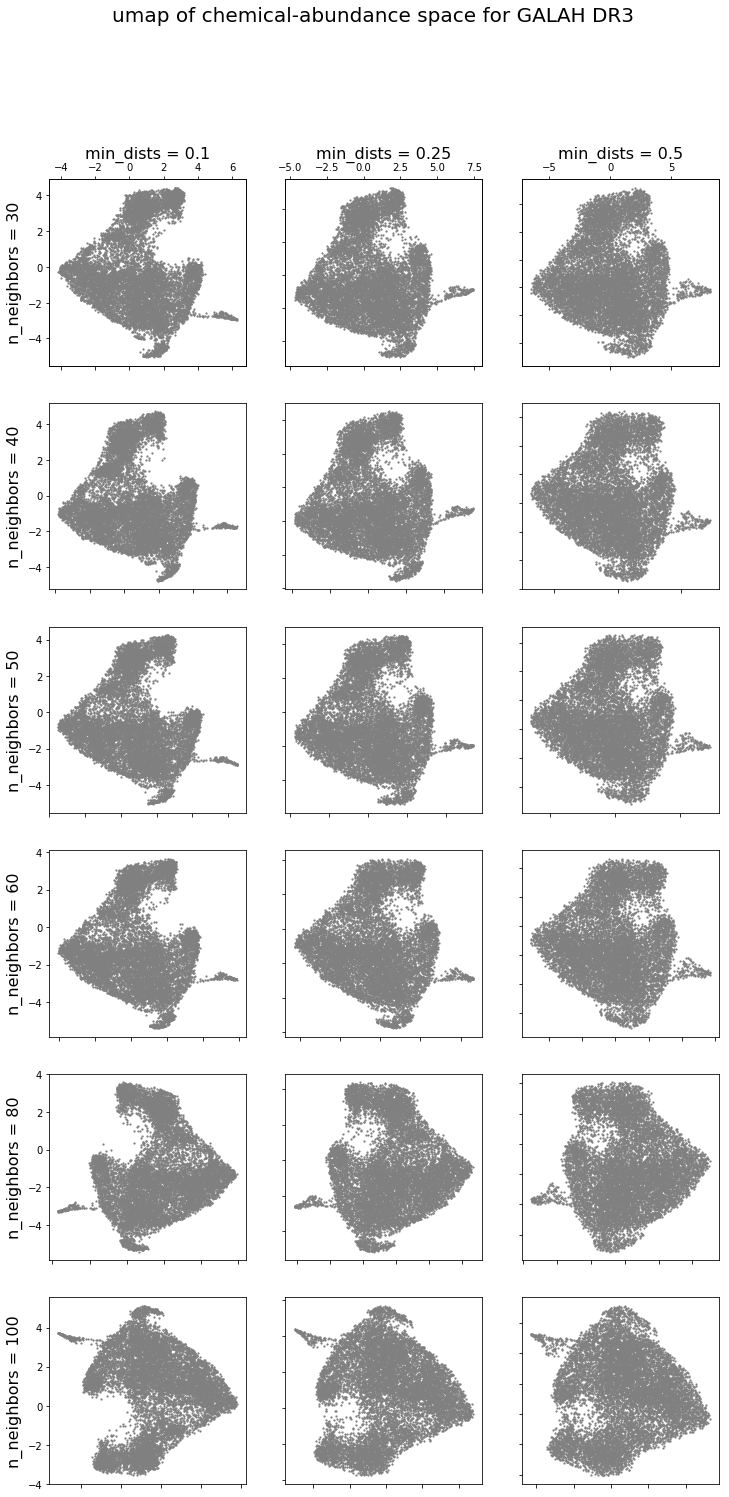

In [38]:
import matplotlib.gridspec as gridspec   #A grid layout to place subplots within a figure.


algname  = ["tSNE", "umap"]  #nom de l'algoritme
colors   = ["orange", "m", "r", "b", "k"]

metric = "euclidean"
## in particular for tsne:
perplexities   = [30, 40, 50, 60, 80, 100] #[5, 10, 20, 30, 40, 50, 60, 80, 100, 150, 200] 
learning_rates = [10, 100] #[1, 10, 100, 500]
## in particular for umap:
n_neighbors  = [30, 40, 50, 60, 80, 100] # [5, 10, 20, 30, 40, 50, 60, 80, 100, 150, 200]
min_dists    = [0.1, 0.25, 0.5]# [0.0, 0.1, 0.25, 0.5, 0.8, 0.99]

# define the optimal hyperparameter values by eye & colour the corresponding panels:
#t_opt = [[ 60, 10],[ 20, 100],[ 60, 100],[ 20, 100],[ 20, 100] ]
#u_opt = [[ 40, .1],[ 20, .1],[ 40, .1],[ 20, .1],[ 20, .1] ]

for ii in [0,1]:
    if ii == 0:
        # tsne
        xx = perplexities
        yy = learning_rates
        #p_opt = t_opt
    else:
        # umap
        xx = n_neighbors
        yy = min_dists
        #p_opt = u_opt
    f = plt.figure(figsize=(4*len(yy), 4*len(xx)))
    gs0 = gridspec.GridSpec(len(xx), len(yy))
    plt.suptitle(algname[ii]+" of chemical-abundance space for GALAH DR3", fontsize=20)
    # Read dimred results:
    results = Table.read("../data/galah_rc_dimred_hyperparametertest.fits")
    # Loop over each subplot:
    for kk, ll in product(range(len(xx)), range(len(yy))):
        ax = plt.Subplot(f, gs0[kk, ll])
        f.add_subplot(ax)
        # Get the relevant columns for the subplot:
        if ii == 0:
            colstring = algname[ii]+"_"+ metric+"_p"+str(xx[kk]) + "_lr"+str(yy[ll])
        else:
            colstring = algname[ii]+"_"+ metric+"_nn"+str(xx[kk]) + "_md"+str(yy[ll])
        # Plot those MoFos:
        scat = plt.scatter(results["X_"+colstring], results["Y_"+colstring], s=5, lw=0, c="grey")
        # Beautify the axes:
        #if xx[kk] == p_opt[jj][0] and yy[ll] == p_opt[jj][1]:
        #    ax.set_facecolor('yellow')
        if ll!=0:
            ax.yaxis.set_major_formatter(NullFormatter())
        else:
            if ii == 0:
                ax.set_ylabel("perplexity = "+str(xx[kk]), fontsize=16)
            else:
                ax.set_ylabel("n_neighbors = "+str(xx[kk]), fontsize=16)
        if kk==0:
            ax2 = ax.twiny()
            ax2.set_xlim(ax.get_xlim())
            if ii == 0:
                ax2.set_xlabel("learning rate = "+str(yy[ll]), fontsize=16)
            else:
                ax2.set_xlabel("min_dists = "+str(yy[ll]), fontsize=16)
        ax.xaxis.set_major_formatter(NullFormatter())
    plt.savefig("../im/galah_rc_"+algname[ii]+"_"+metric+"-metric_parametertest.png", dpi=120)


### Making a big plot colour-coded by [Fe/H]:

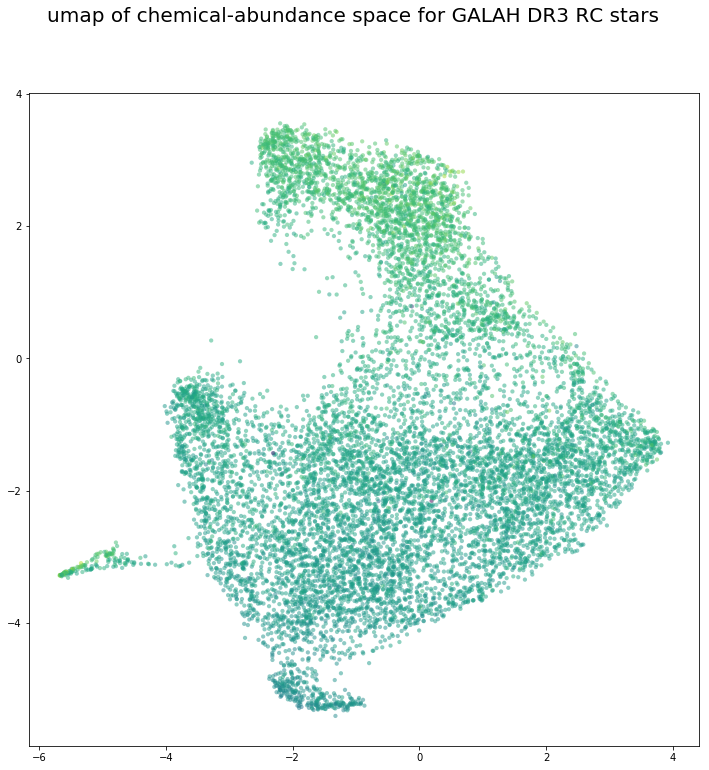

In [39]:
colstring = "umap_euclidean_nn80_md0.1"
#colstring = "tSNE_euclidean_nn40_md0.1"

f = plt.figure(figsize=(12,12))

plt.suptitle("umap of chemical-abundance space for GALAH DR3 RC stars", fontsize=20)
scat = plt.scatter(results["X_"+colstring], results["Y_"+colstring], s=18, lw=0, alpha=0.5, 
                   c=galah_rc.data["mg_fe"], label="GALAH DR3 RC sample")
plt.savefig("../im/umap_galah_rc.png", dpi=120)

In [24]:
galah_rc.get_umap_tsne_colours(p=80, lr=10, nn=80, md=0.1, 
                              metric="euclidean", version="")
galah_rc.get_umap_subsets(nn=80, md=0.1, min_cluster_size=10, min_samples=10)

In [25]:
for ii in galah_rc.subsets:
    print("HDBSCAN subset", ii, ":", np.sum(galah_rc.classcol==ii), "stars")


HDBSCAN subset -1 : 49 stars
HDBSCAN subset 0 : 10764 stars
HDBSCAN subset 1 : 84 stars
HDBSCAN subset 2 : 44 stars


Now we can adapt Fig. 1 from Anders+2018 for our sample, using the automatically found clusters as subgroups: 

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19


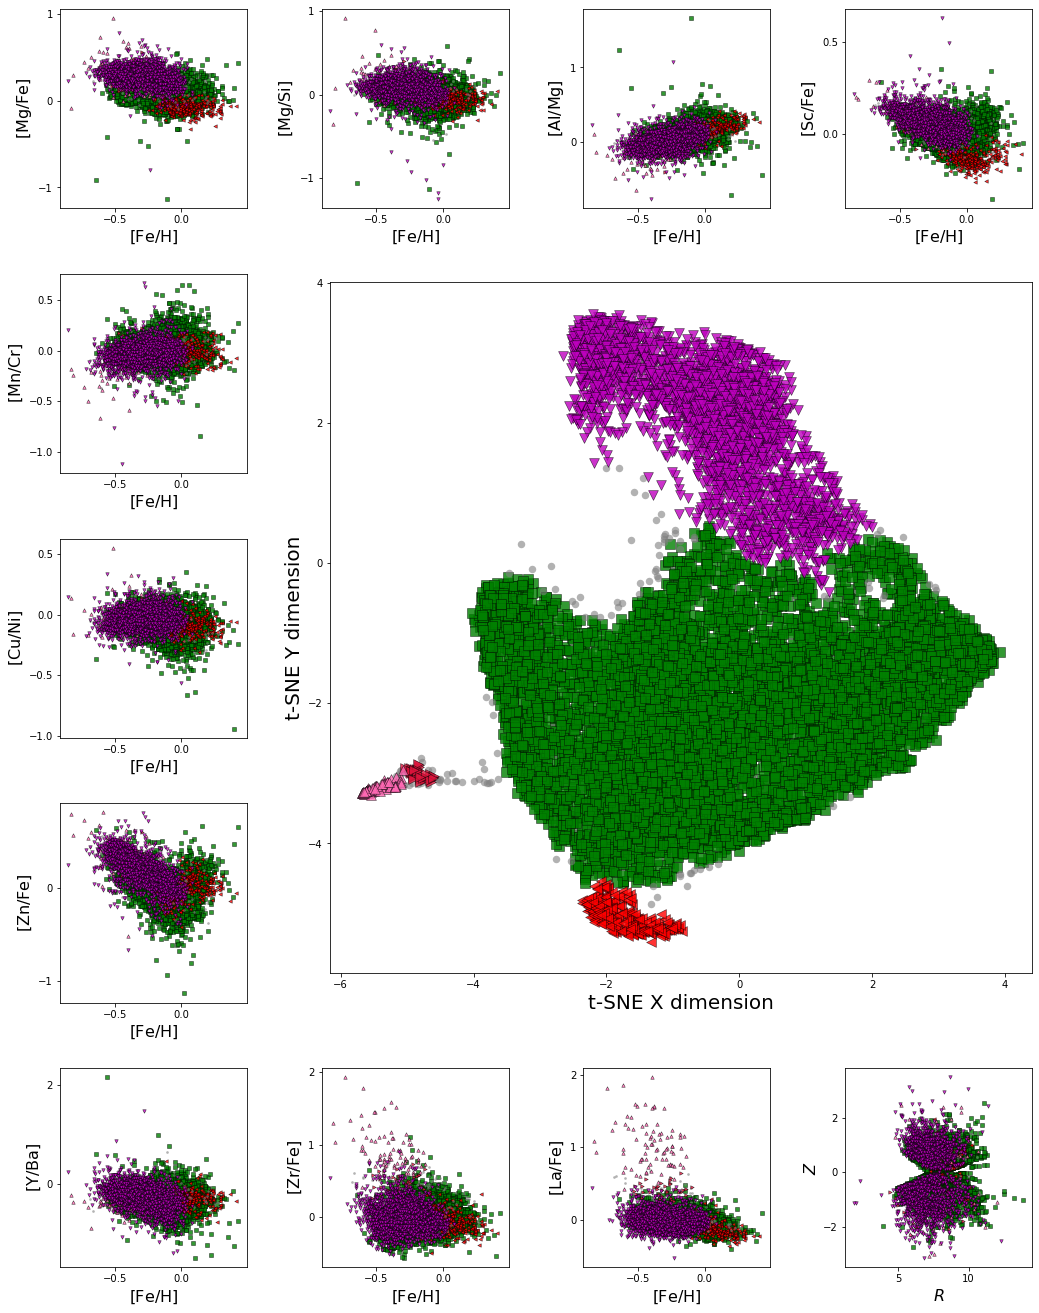

In [23]:
t = galah_rc

# t-SNE + abundances plot

exinds = [ [0,1], [0,2], [0,4], [0,5],
           [0,6], None,  None,  None, 
           [0,7], None,  None,  None, 
           [0,8], None,  None,  None, 
           [0,9],[0,10],[0,11],[13,14] ]
limits = [ None,  None,  None,  None, 
           None,  None,  None,  None, 
           None,  None,  None,  None, 
           None,  None,  None,  None, 
           None,  None,  None,  None ]

order=[5,4,0,3,2,1]#[12,0,7,10,1,2,3,4,5,6,8,9,11] # define the order in which the plot is to be made so that the smaller groups may be seen
#------------------------------------------------------------
# Plot the results
import matplotlib.gridspec as gridspec

g   = plt.figure(figsize=(15, 19))

#################
# abundance plots around
#################
gs = gridspec.GridSpec(5, 4)
gs.update(left=0.08, bottom=0.06, right=0.98, top=0.98,
           wspace=0.4, hspace=0.33)

for jj in range(20):
    print(jj)
    if exinds[jj] != None:
        ax = plt.subplot(gs[int(jj/4), int(jj%4)])
        g.add_subplot(ax)
        for kk in order:
            mask = (t.classcol == t.subsets[kk]) #* (xerr[exinds[jj][1]] < 9.9)
            #ax.errorbar(xx[exinds[jj][0]][mask], xx[exinds[jj][1]][mask],
            #            xerr=xerr[exinds[jj][0]][mask], yerr=xerr[exinds[jj][1]][mask],
            #           ms=0, mec="k", capthick=0, elinewidth=1,
            #           mfc=t.col[kk], alpha=t.al[kk]/4., ecolor=t.col[kk], lw=0,
            #           marker=t.sym[kk], zorder=0)
            ax.scatter(t.colors[exinds[jj][0]][mask], t.colors[exinds[jj][1]][mask],
                       s=t.size[kk], lw=t.lw[kk], edgecolors="k",
                       c=t.col[kk], alpha=t.al[kk],
                       marker=t.sym[kk])
        ax.set_xlabel(t.titles[exinds[jj][0]], fontsize=16)
        ax.set_ylabel(t.titles[exinds[jj][1]], fontsize=16)
        if limits[jj] != None:
            ax.axis(limits[jj])
        ax.locator_params(tight=True, nbins=4)

#################
# t-SNE plot in the center
#################
gs0 = gridspec.GridSpec(1, 1)
gs0.update(left=0.33, bottom=0.275, right=0.98, top=0.78)
ax  = plt.Subplot(g, gs0[0, 0])
g.add_subplot(ax)
for kk in order:
    mask = (t.classcol == t.subsets[kk])
    ax.scatter(t.Xu[mask], t.Yu[mask], s=8*t.size[kk], lw=t.lw[kk], edgecolors="k",
               c=t.col[kk], alpha=t.al[kk], marker=t.sym[kk], label=t.names[kk])
    # Annotate population names
    #if kk < len(t.names):
    #    ax.text(t.Xcoords[kk], t.Ycoords[kk], t.names[kk], fontsize=1.25*t.fsize[kk])
ax.set_xlabel("t-SNE X dimension", fontsize=20)
ax.set_ylabel("t-SNE Y dimension", fontsize=20)

plt.savefig("../im/galah_rc_big-umap-abundsplot.png", dpi=200)  


In [35]:
len(galah_rc.data)

10941

-quin dimred utilitzarem per l'analisis
-quin xdeconv..
-